<a href="https://colab.research.google.com/github/ugisrutinsRSU/RSU_Colab/blob/main/05_cifar10_cnn_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise: Build a CNN from Scratch on CIFAR-10

**Learning outcomes.** By the end of this exercise you will be able to:

1. Design a convolutional neural network architecture from scratch in PyTorch.
2. Set up a reproducible train / validation / test pipeline.
3. Implement a training loop with validation and track learning curves.
4. Diagnose overfitting from loss and accuracy curves.
5. Evaluate a classifier using overall accuracy, per-class accuracy, and a confusion matrix.

**Dataset.** [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html): 60 000 colour images (32 × 32 px) across 10 classes — *airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck*. The official split is 50 000 train + 10 000 test; we will further carve a validation set out of the training images.

**How this notebook works.** Cells marked **TODO** are yours to complete. Everything else is provided. Do not change the random seed or the train/val/test split — they ensure your results are reproducible and comparable to those of your classmates.

**What you will submit.** A completed notebook with every cell executed, plus short written answers to the reflection questions at the end.

---

## 1. Setup and reproducibility

Run this cell as-is. It sets the random seed and picks a device.

In [6]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Load CIFAR-10 and create a validation split

This cell is provided. Read it carefully — make sure you understand **why** we split the training set further into train + validation, rather than just using the test set for tuning.

In [7]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

full_train = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

val_size = 5000
train_size = len(full_train) - val_size
train_set, val_set = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASSES = ("airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck")

print(f"Train: {len(train_set)}  |  Val: {len(val_set)}  |  Test: {len(test_set)}")

C:\Users\ugisr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 45000  |  Val: 5000  |  Test: 10000


## 3. Peek at the data

Run this as-is. Always look at your data before training a model — it catches bugs, and it calibrates your expectations (these images are *tiny*).

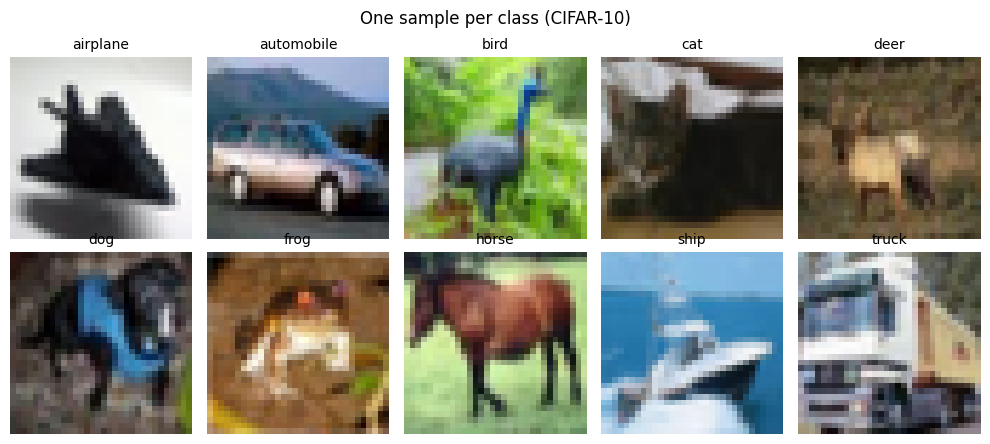

In [8]:
def unnormalize(img_tensor):
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std  = torch.tensor(CIFAR_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

examples = {}
for img, label in full_train:
    if label not in examples:
        examples[label] = img
    if len(examples) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for cls_idx, ax in zip(range(10), axes.flatten()):
    ax.imshow(unnormalize(examples[cls_idx]).permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[cls_idx], fontsize=10)
    ax.axis("off")
plt.suptitle("One sample per class (CIFAR-10)")
plt.tight_layout()
plt.show()

## 4. Define the CNN architecture   **[TODO]**

Build a CNN that takes a $3 \times 32 \times 32$ image and outputs logits over 10 classes. Follow this architecture exactly — do **not** add batch normalization or extra layers yet (we want a clean baseline to analyze).

- **Block 1:** Conv(3 → 32, 3×3, padding=1) → ReLU → Conv(32 → 32, 3×3, padding=1) → ReLU → MaxPool(2)
- **Block 2:** Conv(32 → 64, 3×3, padding=1) → ReLU → Conv(64 → 64, 3×3, padding=1) → ReLU → MaxPool(2)
- **Block 3:** Conv(64 → 128, 3×3, padding=1) → ReLU → MaxPool(2)
- **Classifier head:** Flatten → Linear(? → 256) → ReLU → Dropout(0.5) → Linear(256 → 10)

**Hint.** After three `MaxPool(2)` operations, what is the spatial size of the feature map? That determines the input dimension of the first `Linear` layer.

**Hint.** Return *logits* (no softmax). `nn.CrossEntropyLoss` applies log-softmax internally.

The layers in `__init__` are already given. You only need to write the `forward` method and fill in the flattened-feature size.

In [9]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Block 1
        self.conv1a = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        # Block 2
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # 32x32 -> MaxPool -> 16x16 -> MaxPool -> 8x8 -> MaxPool -> 4x4
        # 128 kanāli × 4 × 4 pikseļi = 2048
        flattened = 128 * 4 * 4  # = 2048
        self.fc1 = nn.Linear(flattened, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1: conv -> relu -> conv -> relu -> maxpool
        x = F.relu(self.conv1a(x))
        x = F.relu(self.conv1b(x))
        x = self.pool(x)           # 32x32 -> 16x16

        # Block 2: conv -> relu -> conv -> relu -> maxpool
        x = F.relu(self.conv2a(x))
        x = F.relu(self.conv2b(x))
        x = self.pool(x)           # 16x16 -> 8x8

        # Block 3: conv -> relu -> maxpool
        x = F.relu(self.conv3(x))
        x = self.pool(x)           # 8x8 -> 4x4

        # Classifier head
        x = torch.flatten(x, 1)   # [batch, 128*4*4] = [batch, 2048]
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)            # logiti — bez softmax
        return x


model = SmallCNN().to(device)

# Sanity check — this should print [2, 10].
dummy = torch.randn(2, 3, 32, 32, device=device)
with torch.no_grad():
    out = model(dummy)
print(f"Output shape: {out.shape}  (expected [2, 10])")

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

Output shape: torch.Size([2, 10])  (expected [2, 10])
Trainable parameters: 666,538


## 5. Loss function and optimizer

Provided. Use Adam with learning rate $10^{-3}$ and cross-entropy loss.

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## 6. Training and validation loop   **[TODO]**

You are given a helper function `run_one_epoch` that runs *either* a training pass (if `optimizer` is passed) or a validation pass (if `optimizer=None`). The outer loop is partially written — complete the body so it:

1. Runs one training epoch on `train_loader` and stores `(train_loss, train_acc)`.
2. Runs one validation pass on `val_loader` and stores `(val_loss, val_acc)`.
3. Appends all four values to `history`.
4. Prints a progress line.

**Important:** call `model.train()` during training and `model.eval()` during validation (the helper does this for you — but remember *why* it matters: dropout behaves differently in each mode). Validation must be inside `torch.no_grad()` so we don't track gradients — again, the helper handles this.

In [11]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    """Run one pass. If `optimizer` is given, train; otherwise evaluate."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_seen = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss    += loss.item() * inputs.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_seen    += inputs.size(0)

    return total_loss / total_seen, total_correct / total_seen


NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    # Apmācības gājiens (optimizer padots -> tiek aprēķināti gradienti)
    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)

    # Validācijas gājiens (optimizer=None -> tikai novērtēšana, bez atpakaļizplatīšanas)
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion, optimizer=None)

    # Saglabājam vēsturi zīmēšanai
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
        f"train_loss={train_loss:.4f}  train_acc={100*train_acc:.1f}%  "
        f"val_loss={val_loss:.4f}  val_acc={100*val_acc:.1f}%"
    )

Epoch 01/10  train_loss=1.6170  train_acc=40.7%  val_loss=1.2481  val_acc=54.8%
Epoch 02/10  train_loss=1.1780  train_acc=57.6%  val_loss=0.9757  val_acc=64.9%
Epoch 03/10  train_loss=0.9744  train_acc=65.6%  val_loss=0.8214  val_acc=70.4%
Epoch 04/10  train_loss=0.8382  train_acc=70.7%  val_loss=0.7837  val_acc=72.4%
Epoch 05/10  train_loss=0.7430  train_acc=74.4%  val_loss=0.7298  val_acc=73.9%
Epoch 06/10  train_loss=0.6651  train_acc=76.8%  val_loss=0.6876  val_acc=76.1%
Epoch 07/10  train_loss=0.6001  train_acc=79.2%  val_loss=0.6720  val_acc=76.6%
Epoch 08/10  train_loss=0.5340  train_acc=81.3%  val_loss=0.6604  val_acc=77.3%
Epoch 09/10  train_loss=0.4835  train_acc=82.9%  val_loss=0.6494  val_acc=77.7%
Epoch 10/10  train_loss=0.4499  train_acc=84.1%  val_loss=0.7116  val_acc=76.5%


## 7. Learning curves

Provided. Run this once your training loop works. These curves are your main diagnostic tool — you will refer to them in the reflection questions.

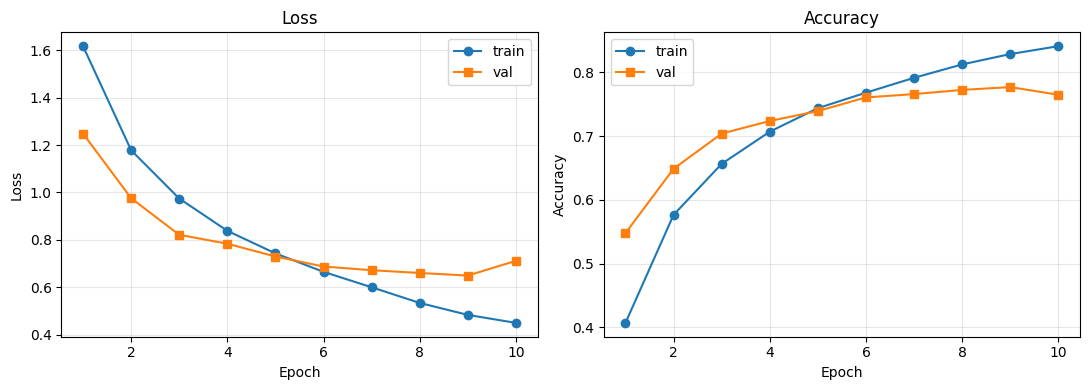

In [15]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epochs, history["train_loss"], "o-", label="train")
ax1.plot(epochs, history["val_loss"],   "s-", label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history["train_acc"], "o-", label="train")
ax2.plot(epochs, history["val_acc"],   "s-", label="val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 8. Final evaluation on the test set

Provided. Run once, and only once. (In a real project, touching the test set repeatedly while tuning hyperparameters makes the final number meaningless — the test set effectively becomes a second validation set.)

In [13]:
test_loss, test_acc = run_one_epoch(model, test_loader, criterion, optimizer=None)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {100 * test_acc:.2f}%")

Test loss: 0.7248
Test accuracy: 76.86%


## 9. Per-class accuracy and confusion matrix   **[TODO]**

Overall test accuracy hides a lot. Compute:

1. **Per-class accuracy** — the fraction of test images from each class that are classified correctly.
2. **A confusion matrix** — a $10 \times 10$ array where entry $(i, j)$ counts how many test images with true class $i$ were predicted as class $j$.

The first part of this cell (collecting `all_preds` and `all_labels`) is provided. Fill in the rest.

Per-class accuracy on test set:
-----------------------------------
  airplane      84.3%
  automobile    88.2%
  bird          64.4%
  cat           62.1%
  deer          70.6%
  dog           68.5%
  frog          70.4%
  horse         84.2%
  ship          87.2%
  truck         88.7%


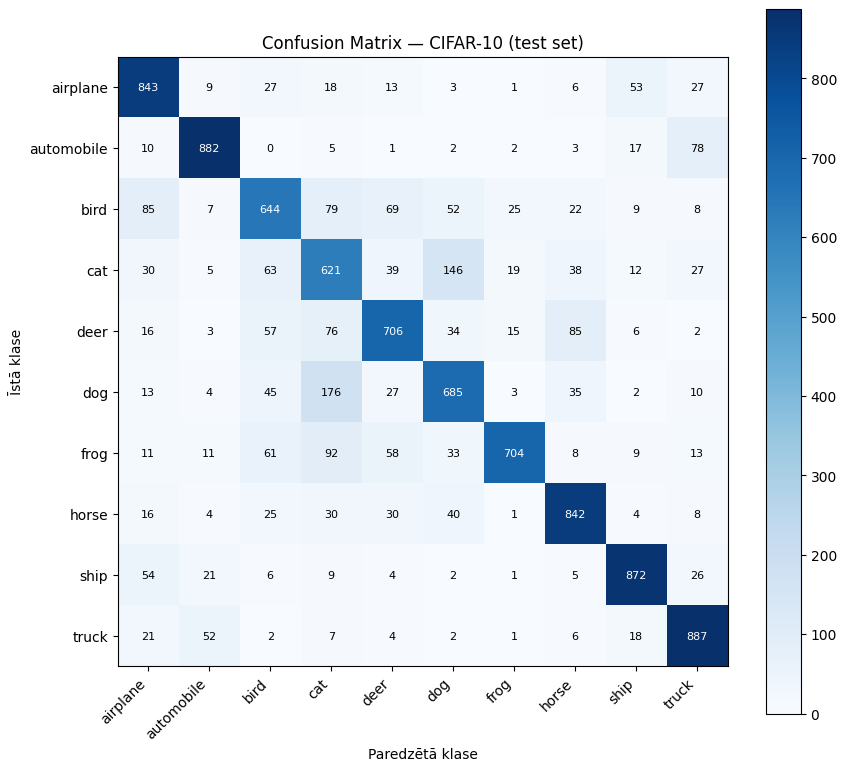

In [16]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds = model(inputs).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# (a) Per-klases precizitāte
print("Per-class accuracy on test set:")
print("-" * 35)
for cls_idx, cls_name in enumerate(CLASSES):
    mask = all_labels == cls_idx          # tikai šīs klases attēli
    cls_acc = (all_preds[mask] == cls_idx).mean()
    print(f"  {cls_name:<12s}  {100 * cls_acc:.1f}%")

# (b) Sajaukuma matrica (confusion matrix)
num_classes = len(CLASSES)
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
for true, pred in zip(all_labels, all_preds):
    conf_matrix[true, pred] += 1

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(conf_matrix, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Paredzētā klase")
ax.set_ylabel("Īstā klase")
ax.set_title("Confusion Matrix — CIFAR-10 (test set)")

# Cipari katrā šūnā
thresh = conf_matrix.max() / 2
for i in range(num_classes):
    for j in range(num_classes):
        color = "white" if conf_matrix[i, j] > thresh else "black"
        ax.text(j, i, str(conf_matrix[i, j]),
                ha="center", va="center", fontsize=8, color=color)

plt.tight_layout()
plt.show()

## 10. Reflection questions

Answer briefly (2–4 sentences each). Write your answers in a new markdown cell directly below each question.

**Q1.** Looking at your loss curves, does the model show signs of overfitting, underfitting, or clean learning? Which specific features of the curves support your answer? 
Overfitting

**Q2.** Which two classes are most often confused with each other in your confusion matrix? Propose a plausible reason based on the visual similarity of the underlying images. 
Cat&dog, automobile&truck

**Q3.** Suggest two concrete changes (to the architecture, optimizer, or data pipeline) that you expect would improve test accuracy, and explain *why* you expect each to help.

**Q4.** After three `MaxPool(2)` layers, a 32 × 32 input becomes 4 × 4 spatially. What would go wrong if we added a fourth `MaxPool(2)` without changing the input size or padding? Answer in terms of the feature map dimensions.

---

*End of exercise.*